<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/DEM_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import ee
import geemap
import xarray as xr

In [ ]:
!pip install xee

In [4]:
import xee
import numpy as np
import pandas as pd

In [5]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

In [7]:
roi = map.draw_last_feature.geometry()

roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          89.515992,
                          22.745789
                        ],
                        [
                          89.515992,
                          24.347097
                        ],
                        [
                          91.712243,
                          24.347097
                        ],
                        [
                          91.712243,
                          22.745789
                        ],
                        [
                          89.515992,
                          22.745789
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [8]:
dem = (
    ee.Image("NASA/NASADEM_HGT/001")
    .select([0],['elevation'])
)

dem

In [9]:
xdem = xr.open_dataset(
    dem,
    engine = 'ee',
    crs = 'EPSG:4326',
    geometry = roi,
    scale = 0.001
)

xdem


<xarray.Dataset> Size: 14MB
Dimensions:    (time: 1, lon: 2196, lat: 1601)
Coordinates:
  * time       (time) datetime64[ns] 8B 2000-02-11
  * lon        (lon) float64 18kB 89.52 89.52 89.52 89.52 ... 91.71 91.71 91.71
  * lat        (lat) float64 13kB 22.75 22.75 22.75 22.75 ... 24.34 24.35 24.35
Data variables:
    elevation  (time, lon, lat) float32 14MB ...
Attributes:
    crs:      EPSG:4326

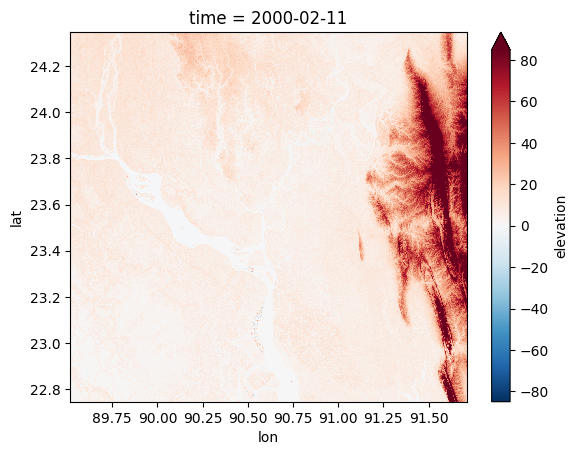

In [10]:
xdem.elevation.plot(
    x = 'lon',
    y = 'lat',
    robust = True
)


In [11]:
df = xdem.to_dataframe()

df


elevation
time       lon       lat                 
2000-02-11 89.516492 22.746289        0.0
                     22.747289        5.0
                     22.748289        5.0
                     22.749289        3.0
                     22.750289        0.0
...                                   ...
           91.711492 24.342289        5.0
                     24.343289        6.0
                     24.344289        5.0
                     24.345289        6.0
                     24.346289        7.0

[3515796 rows x 1 columns]

In [12]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters = 5)

model.fit(df)


KMeans(n_clusters=5)

In [13]:
df['classes'] = model.predict(df)

df

elevation  classes
time       lon       lat                          
2000-02-11 89.516492 22.746289        0.0        0
                     22.747289        5.0        0
                     22.748289        5.0        0
                     22.749289        3.0        0
                     22.750289        0.0        0
...                                   ...      ...
           91.711492 24.342289        5.0        0
                     24.343289        6.0        0
                     24.344289        5.0        0
                     24.345289        6.0        0
                     24.346289        7.0        0

[3515796 rows x 2 columns]

In [14]:
xarr = df.to_xarray().sortby(['lon','lat'])

xarr

<xarray.Dataset> Size: 28MB
Dimensions:    (time: 1, lon: 2196, lat: 1601)
Coordinates:
  * time       (time) datetime64[ns] 8B 2000-02-11
  * lon        (lon) float64 18kB 89.52 89.52 89.52 89.52 ... 91.71 91.71 91.71
  * lat        (lat) float64 13kB 22.75 22.75 22.75 22.75 ... 24.34 24.35 24.35
Data variables:
    elevation  (time, lon, lat) float32 14MB 0.0 5.0 5.0 3.0 ... 6.0 5.0 6.0 7.0
    classes    (time, lon, lat) int32 14MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0

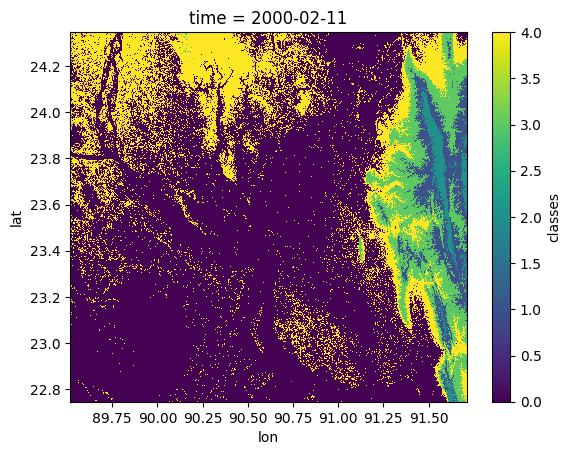

In [15]:
xarr.classes.plot(
    x = 'lon',
    y = 'lat'
)

In [16]:
class_num = np.unique(xarr.classes.values)
class_num


array([0, 1, 2, 3, 4], dtype=int32)

In [17]:
xarr.elevation.where(xarr.classes == 1).mean().values

for i in class_num:
  class_mean = xarr.elevation.where(xarr.classes == i).mean().values.round(2)
  print(f'class {i} average: {class_mean}')
  class_max = xarr.elevation.where(xarr.classes == i).max().values.round(2)
  print(f'class {i} maximum: {class_max}')
  class_min = xarr.elevation.where(xarr.classes == i).min().values.round(2)
  print(f'class {i} minimum: {class_min}')
  print('-----------------------------------')

class 0 average: 4.76
class 0 maximum: 9.0
class 0 minimum: -84.0
-----------------------------------
class 1 average: 72.04
class 1 maximum: 99.0
class 1 minimum: 56.0
-----------------------------------
class 2 average: 127.93
class 2 maximum: 265.0
class 2 minimum: 100.0
-----------------------------------
class 3 average: 40.03
class 3 maximum: 55.0
class 3 minimum: 27.0
-----------------------------------
class 4 average: 13.76
class 4 maximum: 26.0
class 4 minimum: 10.0
-----------------------------------
